# Home Credit Default Risk: Explainability and a Basel-Aligned Scorecard

Notebook 5 of 5. It explains the blended model with exact TreeSHAP, calibrates its output into a probability of default (PD), converts PD into a points score, builds a 10-grade master scale, validates it on the holdout, and computes Basel IRB capital by grade and by segment. It ends by exporting everything the dashboard needs.

## Setup

Imports, seeds and the scorecard constants: 600 points at good:bad odds of 50:1 with 20 points to double the odds, a 0.05% PD floor (Basel III retail), LGD of 45% with a 30% floor (the Basel III LGD floor for other unsecured retail exposures), and 10 grades. `tidy` converts results to JSON-safe values, mapping NaN and infinity to null. `SMOKE` is a switch for a quick check run with a small SHAP subsample; it is off in this version.

In [1]:
import json
import platform
import shutil
import time
from pathlib import Path

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import seaborn as sns
import shap
import sklearn
import xgboost as xgb
from scipy.stats import beta, norm
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, precision_recall_curve, roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold, train_test_split

SMOKE = False
INPUT = Path("/kaggle/input")
OUT = Path("/kaggle/working")
FIG = OUT / "figures"
ART = OUT / "artifacts"
FIG.mkdir(parents=True, exist_ok=True)
ART.mkdir(parents=True, exist_ok=True)
SEED = 42
THREADS = 4
SHAP_ROWS = 2000 if SMOKE else 20000
APP_SAMPLE = 1000 if SMOKE else 5000
PD_FLOOR = 0.0005
LGD_DEFAULT = 0.45
LGD_FLOOR = 0.30
BASE_SCORE, BASE_ODDS, PDO = 600.0, 50.0, 20.0
N_GRADES = 10
SEG_COLS = ["SEG_NAME_CONTRACT_TYPE", "SEG_NAME_INCOME_TYPE", "SEG_NAME_EDUCATION_TYPE", "SEG_NAME_FAMILY_STATUS", "SEG_REGION_RATING_CLIENT", "SEG_AGE_BAND"]
sns.set_theme(style="whitegrid", palette="deep")
START = time.time()


def find_file(name):
    hits = sorted(INPUT.rglob(name))
    if not hits:
        raise FileNotFoundError(name)
    return hits[0]


def save(fig, name):
    fig.savefig(FIG / f"{name}.png", dpi=110, bbox_inches="tight")
    plt.show()


def elapsed():
    return f"{(time.time() - START) / 60:.1f} min"


def tidy(obj):
    if isinstance(obj, dict):
        return {str(k): tidy(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [tidy(v) for v in obj]
    if isinstance(obj, np.ndarray):
        return [tidy(v) for v in obj.tolist()]
    if isinstance(obj, (bool, np.bool_)):
        return bool(obj)
    if isinstance(obj, (int, np.integer)):
        return int(obj)
    if isinstance(obj, (float, np.floating)):
        return round(float(obj), 6) if np.isfinite(obj) else None
    return obj


print(f"smoke={SMOKE} shap_rows={SHAP_ROWS}")

smoke=False shap_rows=20000


**Conclusion.** The smoke switch is off, so SHAP runs on 20,000 holdout applicants and the dashboard sample holds 5,000.

## Load models, predictions and data

Aim: load the two refit models, the blend weight, out-of-fold and holdout margins, and the feature matrix with segment labels and exposure. A check recomputes holdout margins for 200 applicants and compares them with notebook 4's, confirming the models loaded intact.

In [2]:
lgb_path, xgb_path = find_file("lgbm_model.txt"), find_file("xgb_model.json")
lgbm = lgb.Booster(model_file=str(lgb_path))
xgbm = xgb.Booster()
xgbm.load_model(str(xgb_path))
xgbm.set_param({"nthread": THREADS})
W = json.loads(find_file("blend.json").read_text())["w_lgbm"]
metrics = json.loads(find_file("metrics.json").read_text())
fold_metrics = pd.read_csv(find_file("fold_metrics.csv"))
meta = json.loads(find_file("feature_meta.json").read_text())
FEATURES = lgbm.feature_name()
assert FEATURES == list(xgbm.feature_names)
GROUPS = {f: meta["groups"].get(f, "application") for f in FEATURES}
oof = pd.read_parquet(find_file("oof.parquet"))
hold_pred = pd.read_parquet(find_file("holdout_pred.parquet"))
split = pd.read_parquet(find_file("split.parquet"))
data = pd.read_parquet(find_file("features.parquet"), columns=["SK_ID_CURR", "TARGET", "EAD"] + SEG_COLS + FEATURES)
data = data.merge(split, on="SK_ID_CURR", validate="one_to_one")
train = data[data["is_holdout"] == 0].reset_index(drop=True)
holdout = data[data["is_holdout"] == 1].merge(hold_pred[["SK_ID_CURR", "blend"]], on="SK_ID_CURR", validate="one_to_one").reset_index(drop=True)
del data
probe = holdout.iloc[:200]
recomputed = W * lgbm.predict(probe[FEATURES], raw_score=True) + (1 - W) * xgbm.predict(xgb.DMatrix(probe[FEATURES]), output_margin=True)
print(f"model features {len(FEATURES)}, LightGBM weight {W:.2f}")
print(f"training rows {len(train):,}, holdout rows {len(holdout):,}")
print(f"largest gap to notebook 4 holdout margins: {np.abs(recomputed - probe['blend'].to_numpy()).max():.2e}")

model features 723, LightGBM weight 0.70
training rows 246,008, holdout rows 61,503
largest gap to notebook 4 holdout margins: 0.00e+00


**Conclusion.** Both refit models loaded with the same 723 features and a LightGBM weight of 0.70. Recomputed margins for 200 holdout applicants match notebook 4 exactly (largest gap 0.0), so the models and data loaded intact.

## Time the SHAP computation

Aim: time exact TreeSHAP for both models on 500 holdout rows and project the cost of the full subsample, to confirm the subsample size fits the session.

In [3]:
probe = holdout[FEATURES].iloc[:500]
t0 = time.time()
lgbm.predict(probe, pred_contrib=True)
t_lgb = (time.time() - t0) / len(probe)
t0 = time.time()
xgbm.predict(xgb.DMatrix(probe), pred_contribs=True)
t_xgb = (time.time() - t0) / len(probe)
print(f"seconds per row: LightGBM {t_lgb:.5f}, XGBoost {t_xgb:.5f}")
print(f"projected minutes for {SHAP_ROWS:,} rows: LightGBM {t_lgb * SHAP_ROWS / 60:.1f}, XGBoost {t_xgb * SHAP_ROWS / 60:.1f}")

seconds per row: LightGBM 0.00495, XGBoost 0.00080
projected minutes for 20,000 rows: LightGBM 1.7, XGBoost 0.3


**Conclusion.** Exact TreeSHAP costs a few milliseconds per row for LightGBM and roughly five times less for XGBoost (its trees are only three levels deep), so 20,000 rows take a few minutes at most. The subsample size fits comfortably, and the dashboard can afford to compute these values live for a single applicant.

## Exact SHAP values for the blend

Aim: compute TreeSHAP contributions for a stratified holdout subsample with each model's native implementation and combine them with the blend weight. Because SHAP values are additive in log-odds, the blended contributions plus the base value must equal the blended margin; the check below confirms it.

In [4]:
sub_idx, _ = train_test_split(np.arange(len(holdout)), train_size=SHAP_ROWS, stratify=holdout["TARGET"], random_state=SEED)
sub = holdout.iloc[np.sort(sub_idx)].reset_index(drop=True)
Xs = sub[FEATURES]
contrib = W * lgbm.predict(Xs, pred_contrib=True) + (1 - W) * xgbm.predict(xgb.DMatrix(Xs), pred_contribs=True)
shap_values, base_values = contrib[:, :-1], contrib[:, -1]
gap = np.abs(contrib.sum(axis=1) - sub["blend"].to_numpy()).max()
print(f"SHAP rows {len(sub):,}, default rate in subsample {sub['TARGET'].mean():.4f}")
print(f"largest gap between summed contributions and blended margin: {gap:.2e}")
print(f"elapsed {elapsed()}")

SHAP rows 20,000, default rate in subsample 0.0808
largest gap between summed contributions and blended margin: 9.03e-06
elapsed 2.0 min


**Conclusion.** SHAP values were computed for 20,000 holdout applicants with a default rate of 8.08%, matching the holdout. The blended contributions plus the base value reproduce the blended margin to within 0.00001 for every row, which confirms that blending in log-odds keeps the explanation exact.

## Global importance

Aim: rank features by mean absolute SHAP value, sum importance by source table, and show the direction of each top feature's effect with a beeswarm plot.

                                    mean_abs_shap        group
EXT_MEAN                                   0.2265  application
CODE_GENDER                                0.1306  application
EXT_MAX                                    0.1166  application
EXT_MIN                                    0.1035  application
CREDIT_TO_ANNUITY                          0.0993  application
PREV_DAYS_LAST_DUE_1ST_VERSION_MAX         0.0819     previous
NAME_EDUCATION_TYPE                        0.0741  application
X_INS_PAID_TO_CREDIT                       0.0706  cross_table
DAYS_BIRTH                                 0.0662  application
CREDIT_MINUS_GOODS                         0.0660  application
NAME_FAMILY_STATUS                         0.0657  application
DAYS_EMPLOYED                              0.0652  application
EXT_SOURCE_3                               0.0596  application
X_PREV_ANNUITY_TO_CURRENT                  0.0590  cross_table
AMT_ANNUITY                                0.0583  appl

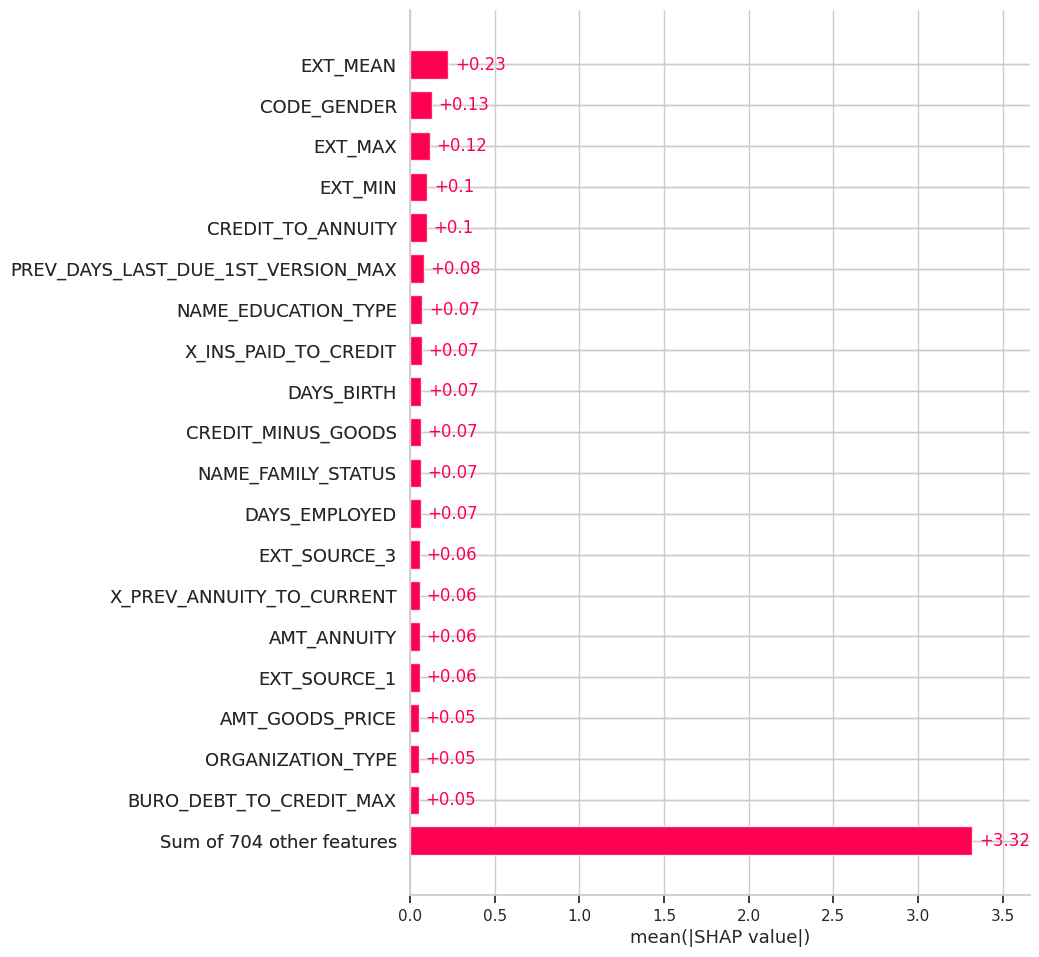

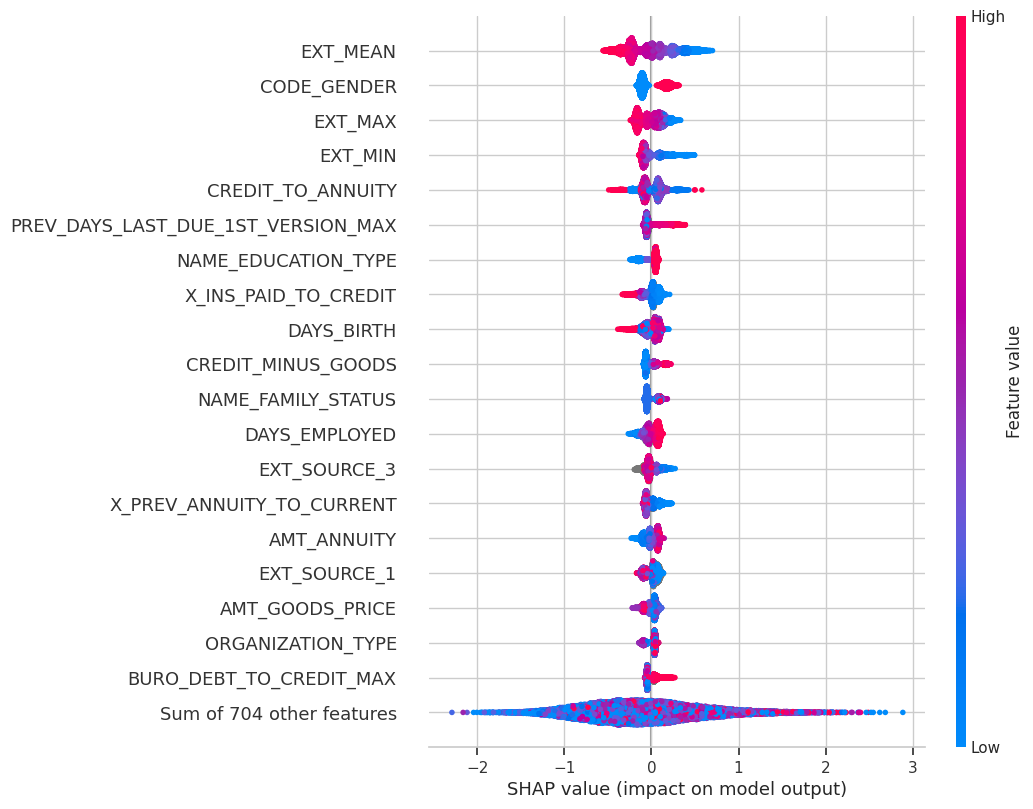

In [5]:
mean_abs = pd.Series(np.abs(shap_values).mean(axis=0), index=FEATURES).sort_values(ascending=False)
top20 = pd.DataFrame({"mean_abs_shap": mean_abs.head(20), "group": [GROUPS[f] for f in mean_abs.head(20).index]})
print(top20.round(4).to_string())
group_share = mean_abs.groupby(lambda f: GROUPS[f]).sum() / mean_abs.sum()
print("\nshare of total mean |SHAP| by source table")
print(group_share.sort_values(ascending=False).round(3).to_string())
explanation = shap.Explanation(values=shap_values, base_values=base_values, data=Xs.to_numpy(), feature_names=FEATURES)
shap.plots.bar(explanation, max_display=20, show=False)
save(plt.gcf(), "01_shap_global")
shap.plots.beeswarm(explanation, max_display=20, show=False)
save(plt.gcf(), "02_shap_beeswarm")

**Conclusion.** EXT_MEAN dominates with a mean absolute SHAP of 0.227, followed by CODE_GENDER (0.131) and the other external-score composites EXT_MAX and EXT_MIN. Affordability (CREDIT_TO_ANNUITY), the latest due date of previous loans, education and the cross-table ratio of instalments paid to the new credit complete the top eight. Application features carry 43% of total importance, previous applications 21% and bureau 16%. CODE_GENDER and NAME_FAMILY_STATUS (eleventh) are protected attributes under fair-lending rules; the served model keeps them because the competition data includes them, and notebook 4 ends with a comparison model trained without them. In the beeswarm, high external scores push risk down while high CODE_GENDER codes (male) push it up.

## Dependence of the top four drivers

Aim: plot each top feature's value against its SHAP value to see the shape of its effect, with a Spearman correlation summarising the direction.

EXT_MEAN: Spearman rho between value and SHAP -0.990, missing share 0.000
CODE_GENDER: Spearman rho between value and SHAP +0.822, missing share 0.000
EXT_MAX: Spearman rho between value and SHAP -0.961, missing share 0.000
EXT_MIN: Spearman rho between value and SHAP -0.911, missing share 0.000


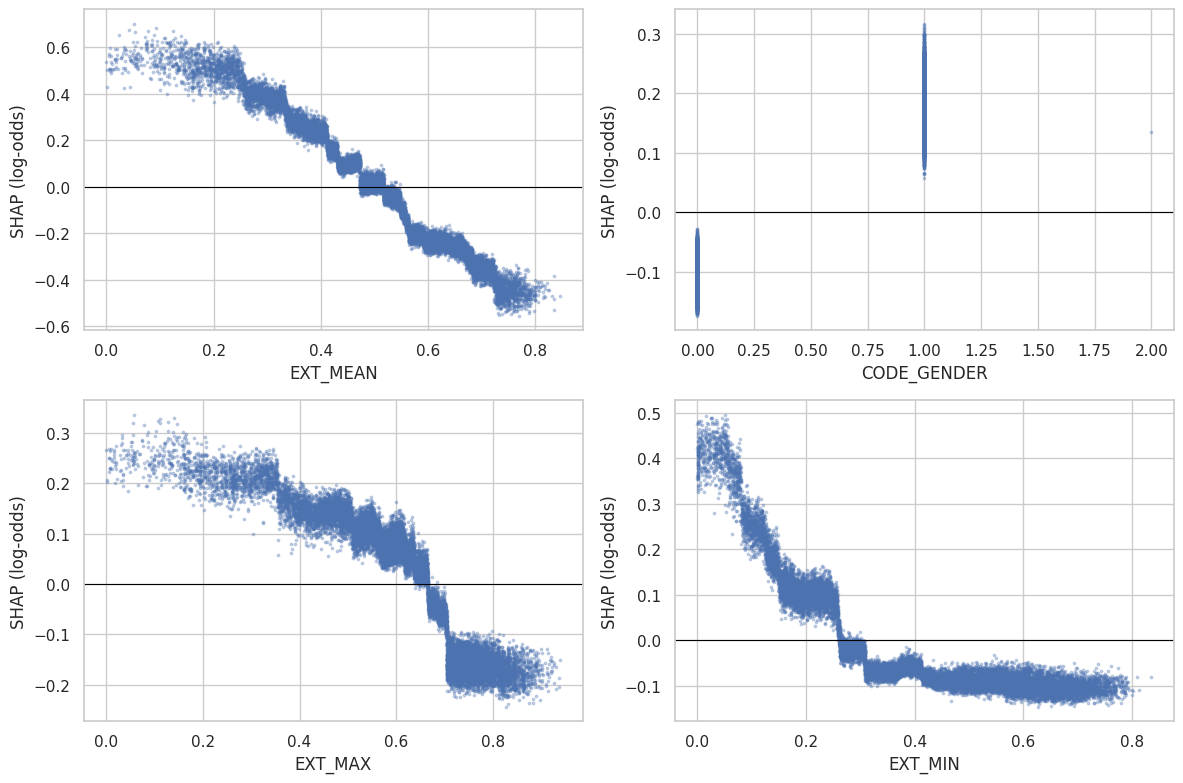

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, name in zip(axes.ravel(), mean_abs.index[:4]):
    j = FEATURES.index(name)
    ax.scatter(Xs[name], shap_values[:, j], s=3, alpha=0.3)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xlabel(name)
    ax.set_ylabel("SHAP (log-odds)")
    rho = pd.Series(Xs[name].to_numpy()).corr(pd.Series(shap_values[:, j]), method="spearman")
    print(f"{name}: Spearman rho between value and SHAP {rho:+.3f}, missing share {Xs[name].isna().mean():.3f}")
fig.tight_layout()
save(fig, "03_shap_dependence")

**Conclusion.** EXT_MEAN has an almost perfectly monotonic effect (Spearman -0.990 between value and SHAP): a higher combined external score always lowers risk. EXT_MAX (-0.961) and EXT_MIN (-0.911) behave the same way. CODE_GENDER (+0.822) splits into two clusters, with male applicants assigned higher risk. None of the four has missing values, because the composites are defined whenever any external score exists.

## Local explanations

Aim: explain the lowest-risk and highest-risk applicants in the subsample with waterfall plots, showing how individual features move each prediction away from the base value.


lowest_risk: SK_ID_CURR 120502, outcome 0, margin -6.296
EXT_MEAN             -0.433
CREDIT_TO_ANNUITY    -0.318
DAYS_EMPLOYED        -0.174
EXT_MAX              -0.160
CREDIT_MINUS_GOODS    0.158


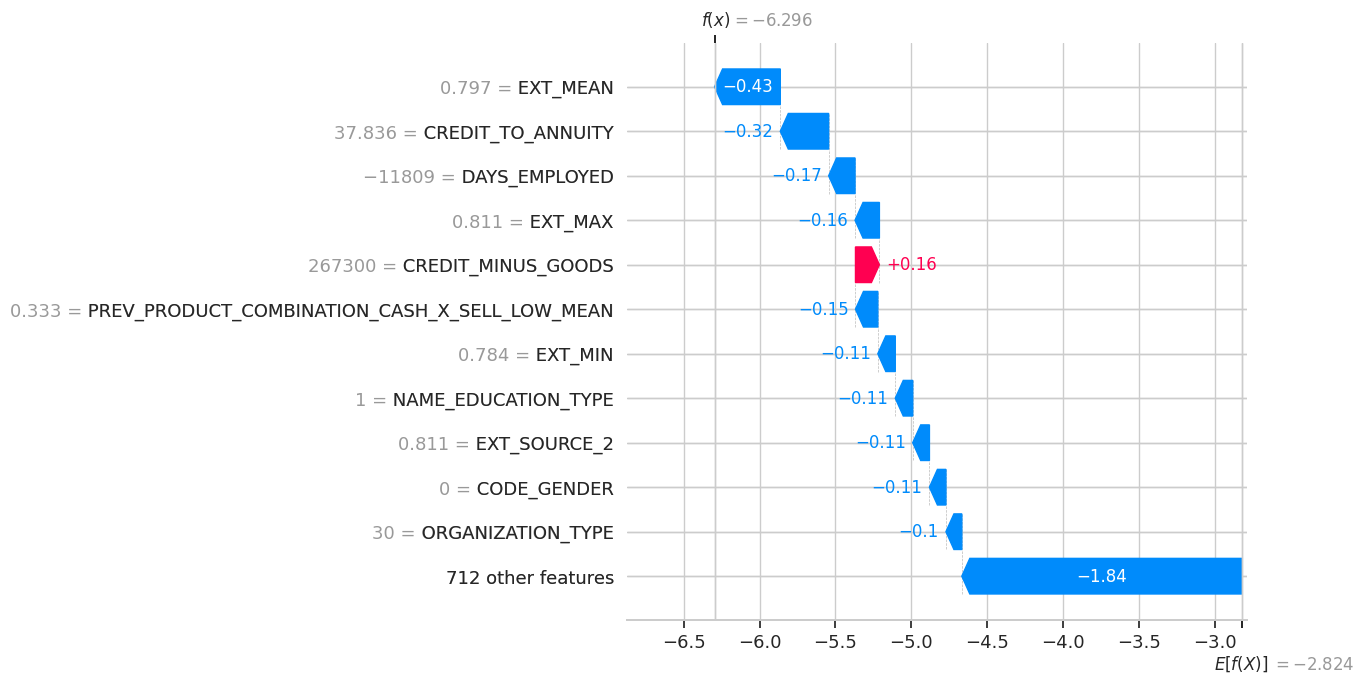


highest_risk: SK_ID_CURR 250277, outcome 1, margin 1.412
EXT_MEAN                0.701
EXT_MIN                 0.470
EXT_MAX                 0.336
EXT_SOURCE_3            0.217
X_INS_PAID_TO_CREDIT    0.133


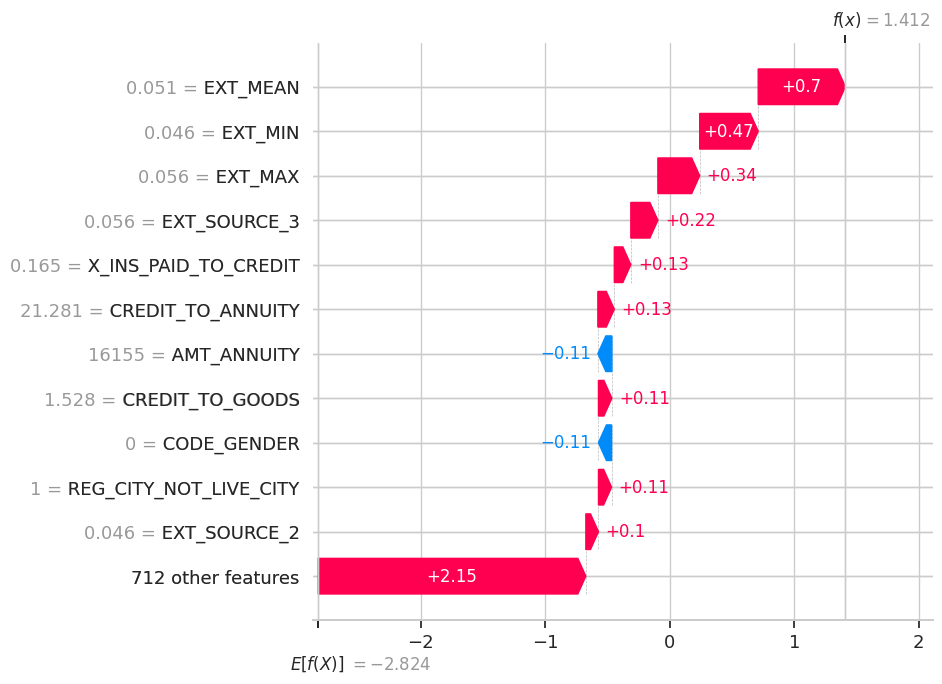

In [7]:
cases = {"lowest_risk": int(np.argmin(sub["blend"].to_numpy())), "highest_risk": int(np.argmax(sub["blend"].to_numpy()))}
for label, i in cases.items():
    row = pd.Series(shap_values[i], index=FEATURES)
    strongest = row.reindex(row.abs().sort_values(ascending=False).index[:5])
    print(f"\n{label}: SK_ID_CURR {sub.at[i, 'SK_ID_CURR']}, outcome {sub.at[i, 'TARGET']}, margin {sub.at[i, 'blend']:.3f}")
    print(strongest.round(3).to_string())
    shap.plots.waterfall(explanation[i], max_display=12, show=False)
    save(plt.gcf(), f"04_waterfall_{label}")

**Conclusion.** The lowest-risk applicant (margin -6.30, about a 0.2% raw probability) repaid; their score is driven down mainly by a high EXT_MEAN (-0.43) and a high credit-to-annuity ratio, a proxy for a long loan term (CREDIT_TO_ANNUITY, -0.32). The highest-risk applicant (margin +1.41, about 80%) defaulted, and almost all of the push comes from very low external scores: EXT_MEAN +0.70, EXT_MIN +0.47, EXT_MAX +0.34 and EXT_SOURCE_3 +0.22. Both cases show the model leaning heavily on the external scores, consistent with the global ranking.

## Drivers by segment

Aim: for each scorecard segment, list the three features with the highest mean absolute SHAP value, to see whether different populations are driven by different signals.

In [8]:
abs_frame = pd.DataFrame(np.abs(shap_values), columns=FEATURES)
drivers = {}
for seg in SEG_COLS:
    counts = sub[seg].value_counts()
    drivers[seg] = {str(level): abs_frame.loc[idx].mean().nlargest(3).index.tolist() for level, idx in sub.groupby(seg).groups.items()}
    print(f"\n{seg}")
    for level, names in drivers[seg].items():
        print(f"  {level} (n={counts[level]}): {', '.join(names)}")


SEG_NAME_CONTRACT_TYPE
  Cash loans (n=18089): EXT_MEAN, CODE_GENDER, EXT_MAX
  Revolving loans (n=1911): EXT_MEAN, EXT_MAX, CODE_GENDER

SEG_NAME_INCOME_TYPE
  Commercial associate (n=4643): EXT_MEAN, CODE_GENDER, EXT_MAX
  Maternity leave (n=1): PREV_DAYS_LAST_DUE_1ST_VERSION_MAX, INS_LAST10_DPD_MEAN, EXT_MEAN
  Pensioner (n=3620): EXT_MEAN, CODE_GENDER, EXT_MAX
  State servant (n=1402): EXT_MEAN, CODE_GENDER, EXT_MAX
  Student (n=1): DAYS_BIRTH, EXT_MEAN, NAME_EDUCATION_TYPE
  Working (n=10333): EXT_MEAN, CODE_GENDER, EXT_MAX

SEG_NAME_EDUCATION_TYPE
  Academic degree (n=15): EXT_MEAN, NAME_EDUCATION_TYPE, CREDIT_TO_ANNUITY
  Higher education (n=4906): EXT_MEAN, NAME_EDUCATION_TYPE, CODE_GENDER
  Incomplete higher (n=665): EXT_MEAN, CODE_GENDER, EXT_MAX
  Lower secondary (n=236): EXT_MEAN, CODE_GENDER, EXT_MAX
  Secondary / secondary special (n=14178): EXT_MEAN, CODE_GENDER, EXT_MAX

SEG_NAME_FAMILY_STATUS
  Civil marriage (n=1960): EXT_MEAN, CODE_GENDER, EXT_MAX
  Married (n=12746

**Conclusion.** The same drivers lead in every sizeable segment: EXT_MEAN first, then CODE_GENDER and EXT_MAX. The exceptions are informative: for applicants with higher education, NAME_EDUCATION_TYPE is the second driver, and for applicants under 30, EXT_MIN replaces CODE_GENDER. Groups with one or two applicants, such as students and maternity leave, show different drivers, but they are too small to interpret.

## Calibrate PD

Aim: turn blended margins into probabilities that match observed default rates. Platt scaling and isotonic regression are compared by 5-fold cross-validated Brier score on the out-of-fold margins; the winner is fitted on all of them. The holdout only confirms the choice.

In [9]:
m_oof, y_oof = oof["blend"].to_numpy(), oof["TARGET"].to_numpy()
m_hold, y_hold = holdout["blend"].to_numpy(), holdout["TARGET"].to_numpy()
cv_brier = {"platt": [], "isotonic": []}
for tr, va in StratifiedKFold(5, shuffle=True, random_state=SEED).split(m_oof.reshape(-1, 1), y_oof):
    platt_k = LogisticRegression(C=1e6).fit(m_oof[tr].reshape(-1, 1), y_oof[tr])
    cv_brier["platt"].append(brier_score_loss(y_oof[va], platt_k.predict_proba(m_oof[va].reshape(-1, 1))[:, 1]))
    iso_k = IsotonicRegression(out_of_bounds="clip", y_min=0.0, y_max=1.0).fit(m_oof[tr], y_oof[tr])
    cv_brier["isotonic"].append(brier_score_loss(y_oof[va], iso_k.predict(m_oof[va])))
cv_brier = {k: float(np.mean(v)) for k, v in cv_brier.items()}
METHOD = min(cv_brier, key=cv_brier.get)
platt = LogisticRegression(C=1e6).fit(m_oof.reshape(-1, 1), y_oof)
iso = IsotonicRegression(out_of_bounds="clip", y_min=0.0, y_max=1.0).fit(m_oof, y_oof)
if METHOD == "platt":
    CALIBRATOR = {"method": "platt", "a": float(platt.coef_[0, 0]), "b": float(platt.intercept_[0])}
else:
    CALIBRATOR = {"method": "isotonic", "x": iso.X_thresholds_.tolist(), "y": iso.y_thresholds_.tolist()}


def calibrate(margin):
    margin = np.asarray(margin, dtype=float)
    if CALIBRATOR["method"] == "platt":
        p = 1 / (1 + np.exp(-(CALIBRATOR["a"] * margin + CALIBRATOR["b"])))
    else:
        p = np.interp(margin, CALIBRATOR["x"], CALIBRATOR["y"])
    return np.clip(p, PD_FLOOR, 0.9999)


pd_oof, pd_hold = calibrate(m_oof), calibrate(m_hold)
hold_brier = {
    "uncalibrated": brier_score_loss(y_hold, 1 / (1 + np.exp(-m_hold))),
    "platt": brier_score_loss(y_hold, platt.predict_proba(m_hold.reshape(-1, 1))[:, 1]),
    "isotonic": brier_score_loss(y_hold, iso.predict(m_hold)),
}
print("5-fold Brier on OOF margins: " + ", ".join(f"{k} {v:.6f}" for k, v in cv_brier.items()))
print(f"chosen method: {METHOD}")
print("holdout Brier: " + ", ".join(f"{k} {v:.6f}" for k, v in hold_brier.items()))
print(f"holdout Brier with chosen calibrator and PD floor {brier_score_loss(y_hold, pd_hold):.6f}")
print(f"holdout mean PD {pd_hold.mean():.4f} against default rate {y_hold.mean():.4f}")

5-fold Brier on OOF margins: platt 0.065383, isotonic 0.065400
chosen method: platt
holdout Brier: uncalibrated 0.064791, platt 0.064787, isotonic 0.064792
holdout Brier with chosen calibrator and PD floor 0.064787
holdout mean PD 0.0808 against default rate 0.0807


**Conclusion.** Platt scaling wins the cross-validated comparison on out-of-fold margins (Brier 0.065383 against 0.065400 for isotonic regression), and the holdout agrees (0.064787 against 0.064792). The gain over the raw model probabilities is tiny (0.064791 uncalibrated) because the boosted models were already close to calibrated, but the step guarantees it. The calibrated mean PD on the holdout is 8.08% against an observed default rate of 8.07%.

## Reliability and the points scale

Aim: check calibration on the holdout by PD decile, then convert PD to points with `Score = Offset + Factor * ln(odds)`, where `Factor = 20 / ln 2` and `Offset = 600 - Factor * ln 50`, and compare score distributions of payers and defaulters.

     predicted  observed  count
bin                            
0       0.0086    0.0089   6151
1       0.0154    0.0158   6150
2       0.0218    0.0174   6150
3       0.0293    0.0272   6150
4       0.0390    0.0379   6151
5       0.0520    0.0493   6150
6       0.0707    0.0725   6150
7       0.0998    0.1033   6150
8       0.1529    0.1595   6150
9       0.3180    0.3156   6151
score scaling: factor 28.8539, offset 487.1229
holdout scores from 432 to 671, median 575


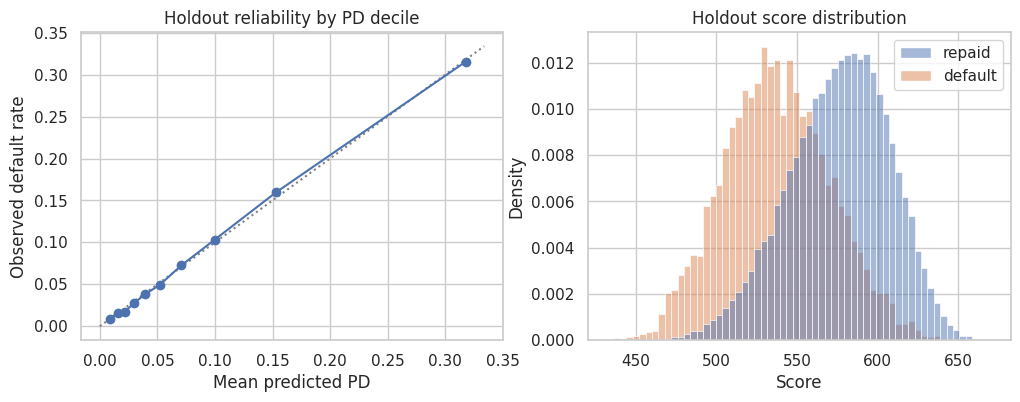

In [10]:
rel = pd.DataFrame({"pd": pd_hold, "y": y_hold})
rel["bin"] = pd.qcut(rel["pd"].rank(method="first"), 10, labels=False)
reliability = rel.groupby("bin").agg(predicted=("pd", "mean"), observed=("y", "mean"), count=("y", "size"))
print(reliability.round(4).to_string())
FACTOR = PDO / np.log(2)
OFFSET = BASE_SCORE - FACTOR * np.log(BASE_ODDS)


def to_score(pd_):
    return OFFSET + FACTOR * np.log((1 - pd_) / pd_)


score_oof, score_hold = to_score(pd_oof), to_score(pd_hold)
print(f"score scaling: factor {FACTOR:.4f}, offset {OFFSET:.4f}")
print(f"holdout scores from {score_hold.min():.0f} to {score_hold.max():.0f}, median {np.median(score_hold):.0f}")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
top = reliability[["predicted", "observed"]].to_numpy().max() * 1.05
axes[0].plot([0, top], [0, top], color="grey", linestyle=":")
axes[0].plot(reliability["predicted"], reliability["observed"], marker="o")
axes[0].set_xlabel("Mean predicted PD")
axes[0].set_ylabel("Observed default rate")
axes[0].set_title("Holdout reliability by PD decile")
sns.histplot(x=score_hold, hue=np.where(y_hold == 1, "default", "repaid"), stat="density", common_norm=False, bins=60, ax=axes[1])
axes[1].set_xlabel("Score")
axes[1].set_title("Holdout score distribution")
save(fig, "05_calibration_and_scores")

**Conclusion.** Predicted and observed default rates line up closely in every holdout decile, from 0.86% against 0.89% in the safest tenth to 31.8% against 31.6% in the riskiest; the largest gap is 0.66 percentage points, in the ninth decile (15.3% predicted against 16.0% observed). The points scale uses a factor of 28.85 and an offset of 487.12, and holdout scores run from 432 to 671 with a median of 575. Defaulters' scores peak around 530 and payers' around 590, with substantial overlap, as an AUC near 0.80 implies.

## Build the master scale

Aim: cut the out-of-fold scores at their deciles into 10 grades, grade 1 best and grade 10 worst, merging neighbours if default rates ever fail to rise. Each grade's PD is its out-of-fold default rate, floored at 0.05%.

In [11]:
def grade_of(score, cuts):
    return len(cuts) + 1 - np.searchsorted(cuts, score, side="right")


cutoffs = sorted(set(np.round(np.quantile(score_oof, np.linspace(0, 1, N_GRADES + 1)[1:-1])).tolist()))
merges = 0
while True:
    rates = pd.Series(y_oof).groupby(grade_of(score_oof, cutoffs)).mean().sort_index()
    inverted = [g for g, nxt in zip(rates.index[:-1], rates.index[1:]) if rates[nxt] <= rates[g]]
    if not inverted:
        break
    cutoffs.pop(len(cutoffs) - int(inverted[0]))
    merges += 1
grade_oof = grade_of(score_oof, cutoffs)
GRADES = list(range(1, len(cutoffs) + 2))
oof_table = pd.DataFrame({"grade": grade_oof, "y": y_oof}).groupby("grade")["y"].agg(count="size", defaults="sum", rate="mean")
GRADE_PD = {int(g): float(max(r, PD_FLOOR)) for g, r in oof_table["rate"].items()}
bounds = [-np.inf] + cutoffs + [np.inf]
master = pd.DataFrame({
    "grade": GRADES,
    "score_min": [bounds[len(cutoffs) + 1 - g] for g in GRADES],
    "score_max": [bounds[len(cutoffs) + 2 - g] for g in GRADES],
})
master["grade_pd"] = master["grade"].map(GRADE_PD)
master["oof_count"] = master["grade"].map(oof_table["count"])
master["oof_rate"] = master["grade"].map(oof_table["rate"])
print(f"cut-offs {cutoffs}, merges needed {merges}")
print(master.round(5).to_string(index=False))

cut-offs [528.0, 544.0, 556.0, 566.0, 575.0, 584.0, 592.0, 601.0, 614.0], merges needed 0
 grade  score_min  score_max  grade_pd  oof_count  oof_rate
     1      614.0        inf   0.00797      23845   0.00797
     2      601.0      614.0   0.01409      26471   0.01409
     3      592.0      601.0   0.01894      23554   0.01894
     4      584.0      592.0   0.02748      23289   0.02748
     5      575.0      584.0   0.03773      26317   0.03773
     6      566.0      575.0   0.05435      24878   0.05435
     7      556.0      566.0   0.07464      24772   0.07464
     8      544.0      556.0   0.10698      24556   0.10698
     9      528.0      544.0   0.15838      23482   0.15838
    10       -inf      528.0   0.30877      24844   0.30877


**Conclusion.** The out-of-fold deciles give cut-offs at 528, 544, 556, 566, 575, 584, 592, 601 and 614, and default rates already rise strictly from grade to grade, so no merges were needed. Grade PDs run from 0.80% in grade 1 to 30.88% in grade 10, roughly doubling every two or three grades, with 23,000 to 26,500 out-of-fold applicants per grade. The 0.05% PD floor never binds because the safest grade sits well above it.

## Validate the master scale on the holdout

Aim: apply the grades to the holdout and test them three ways: whether default rates rise grade by grade, a Jeffreys test per grade (the ECB's PD back-test; a p-value below 0.05 means the grade PD looks too low for the defaults observed), and the population stability index (PSI) of the grade mix between out-of-fold and holdout, where below 0.10 is stable.

       count  defaults     rate  grade_pd  jeffreys_p result
grade                                                       
1       6038        54  0.00894   0.00797     0.19510   pass
2       6707       105  0.01566   0.01409     0.13907   pass
3       6078       109  0.01793   0.01894     0.71321   pass
4       5737       156  0.02719   0.02748     0.54828   pass
5       6482       249  0.03841   0.03773     0.38313   pass
6       6097       304  0.04986   0.05435     0.94025   pass
7       6214       463  0.07451   0.07464     0.51301   pass
8       6120       642  0.10490   0.10698     0.69917   pass
9       5779       913  0.15799   0.15838     0.53081   pass
10      6251      1970  0.31515   0.30877     0.13741   pass
holdout default rate rises with grade: True
grades failing the Jeffreys test at 5%: 0 of 10
PSI of grade mix, OOF vs holdout: 0.00025
holdout AUC using the grade alone: 0.7925


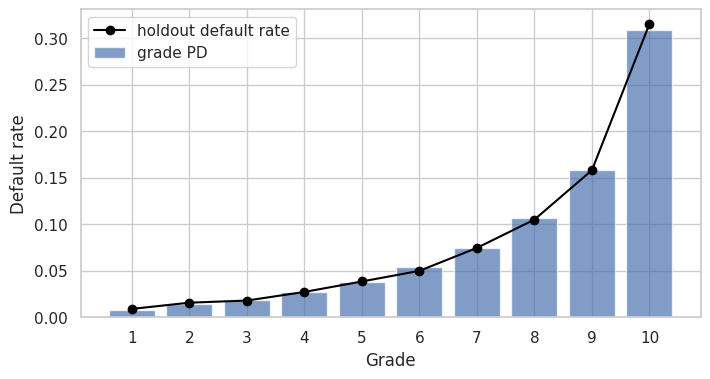

In [12]:
grade_hold = grade_of(score_hold, cutoffs)
val = pd.DataFrame({"grade": grade_hold, "y": y_hold}).groupby("grade")["y"].agg(count="size", defaults="sum", rate="mean").reindex(GRADES, fill_value=0)
val["grade_pd"] = val.index.map(GRADE_PD)
val["jeffreys_p"] = beta.cdf(val["grade_pd"], val["defaults"] + 0.5, val["count"] - val["defaults"] + 0.5)
val["result"] = np.where(val["jeffreys_p"] < 0.05, "PD too low", "pass")
share_oof = pd.Series(grade_oof).value_counts(normalize=True).reindex(GRADES, fill_value=1e-6)
share_hold = pd.Series(grade_hold).value_counts(normalize=True).reindex(GRADES, fill_value=1e-6)
PSI = float(((share_hold - share_oof) * np.log(share_hold / share_oof)).sum())
print(val.round(5).to_string())
print(f"holdout default rate rises with grade: {val['rate'].is_monotonic_increasing}")
print(f"grades failing the Jeffreys test at 5%: {int((val['result'] != 'pass').sum())} of {len(GRADES)}")
print(f"PSI of grade mix, OOF vs holdout: {PSI:.5f}")
print(f"holdout AUC using the grade alone: {roc_auc_score(y_hold, grade_hold):.4f}")
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(val.index, val["grade_pd"], label="grade PD", alpha=0.7)
ax.plot(val.index, val["rate"], color="black", marker="o", label="holdout default rate")
ax.set_xlabel("Grade")
ax.set_ylabel("Default rate")
ax.set_xticks(GRADES)
ax.legend()
save(fig, "06_master_scale")

**Conclusion.** The holdout confirms the scale on all three tests. Default rates rise with every grade, from 0.89% in grade 1 to 31.5% in grade 10. No grade fails the Jeffreys test (p-values from 0.137 to 0.940), so no grade PD is too low for the defaults observed. The PSI of the grade mix is 0.00025, far below the 0.10 stability threshold. Using only the grade as a score gives an AUC of 0.7925 against 0.7991 for the continuous score, so the 10-grade bucketing costs 0.007 of ranking power.

## Capital under the Basel IRB formula

Aim: compute expected loss and risk-weighted assets for every holdout applicant using the IRB formula for other retail exposures: asset correlation between 3% and 16% depending on PD, the 99.9% conditional default rate, no maturity adjustment, the pooled grade PD, LGD 45% and EAD equal to the credit amount. A reference value at PD 1% checks the implementation.

reference: PD 1%, LGD 45% gives K 0.03661818 and risk weight 45.7727%
       count      exposure            el           rwa  risk_weight
GRADE                                                              
1       6038  3.732400e+09  1.338311e+07  1.541162e+09       0.4129
2       6707  4.159215e+09  2.637317e+07  2.173768e+09       0.5226
3       6078  3.874615e+09  3.301500e+07  2.215415e+09       0.5718
4       5737  3.600855e+09  4.452945e+07  2.230150e+09       0.6193
5       6482  4.038035e+09  6.856389e+07  2.609432e+09       0.6462
6       6097  3.710568e+09  9.074320e+07  2.485100e+09       0.6697
7       6214  3.654066e+09  1.227340e+08  2.560205e+09       0.7006
8       6120  3.586113e+09  1.726390e+08  2.771565e+09       0.7729
9       5779  3.172625e+09  2.261113e+08  2.878636e+09       0.9073
10      6251  3.236588e+09  4.497078e+08  3.746378e+09       1.1575
exposure 36,765,080,145, EL 1,247,799,915 (3.394%), RWA 25,211,811,398, RWA density 68.575%, capital at 8% 2,016,9

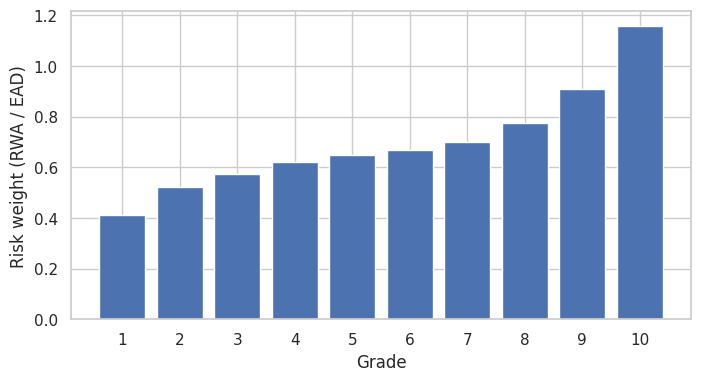

In [13]:
def irb_k(pd_, lgd):
    pd_ = np.asarray(pd_, dtype=float)
    weight = (1 - np.exp(-35 * pd_)) / (1 - np.exp(-35))
    r = 0.03 * weight + 0.16 * (1 - weight)
    return lgd * norm.cdf((norm.ppf(pd_) + np.sqrt(r) * norm.ppf(0.999)) / np.sqrt(1 - r)) - pd_ * lgd


k_ref = float(irb_k(0.01, 0.45))
print(f"reference: PD 1%, LGD 45% gives K {k_ref:.8f} and risk weight {12.5 * k_ref:.4%}")
port = holdout[["SK_ID_CURR", "TARGET", "EAD"] + SEG_COLS].copy()
port["PD"], port["SCORE"], port["GRADE"] = pd_hold, score_hold, grade_hold
port["GRADE_PD"] = port["GRADE"].map(GRADE_PD)
port["EL"] = port["GRADE_PD"] * LGD_DEFAULT * port["EAD"]
port["RWA"] = 12.5 * irb_k(port["GRADE_PD"].to_numpy(), LGD_DEFAULT) * port["EAD"]
capital = port.groupby("GRADE").agg(count=("SK_ID_CURR", "size"), exposure=("EAD", "sum"), el=("EL", "sum"), rwa=("RWA", "sum"))
capital["risk_weight"] = capital["rwa"] / capital["exposure"]
print(capital.round(4).to_string())
total = capital[["exposure", "el", "rwa"]].sum()
print(f"exposure {total['exposure']:,.0f}, EL {total['el']:,.0f} ({total['el'] / total['exposure']:.3%}), RWA {total['rwa']:,.0f}, RWA density {total['rwa'] / total['exposure']:.3%}, capital at 8% {0.08 * total['rwa']:,.0f}")
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(capital.index, capital["risk_weight"])
ax.set_xlabel("Grade")
ax.set_ylabel("Risk weight (RWA / EAD)")
ax.set_xticks(GRADES)
save(fig, "07_risk_weight_by_grade")

**Conclusion.** The implementation matches the reference: PD 1% with LGD 45% gives K = 0.0366 and a risk weight of 45.77%. Across the 61,503 holdout applicants the exposure is 36.8 billion, expected loss 1.25 billion (3.39% of exposure) and risk-weighted assets 25.2 billion, an RWA density of 68.6% and minimum capital of 2.02 billion at 8%. Risk weights rise from 41.3% in grade 1 to 115.8% in grade 10, so the riskiest grade needs almost three times the capital per unit of exposure.

## Segment-level view

Aim: aggregate exposure, mean PD, observed default rate, expected loss and RWA by each of the six segments, and compare RWA density (capital intensity) across segment levels.


SEG_NAME_CONTRACT_TYPE
                        count      exposure  mean_pd  observed            el           rwa  rwa_density
SEG_NAME_CONTRACT_TYPE                                                                                 
Revolving loans          5831  1.916325e+09   0.0561    0.0542  4.128116e+07  1.166464e+09       0.6087
Cash loans              55672  3.484876e+10   0.0833    0.0835  1.206519e+09  2.404535e+10       0.6900

SEG_NAME_INCOME_TYPE
                      count      exposure  mean_pd  observed            el           rwa  rwa_density
SEG_NAME_INCOME_TYPE                                                                                 
Businessman               1  2.250000e+06   0.0216    0.0000  1.917190e+04  1.286498e+06       0.5718
Pensioner             11228  6.016676e+09   0.0525    0.0550  1.483863e+08  3.847317e+09       0.6394
State servant          4185  2.757744e+09   0.0635    0.0538  7.336553e+07  1.766211e+09       0.6405
Commercial associate  14344 

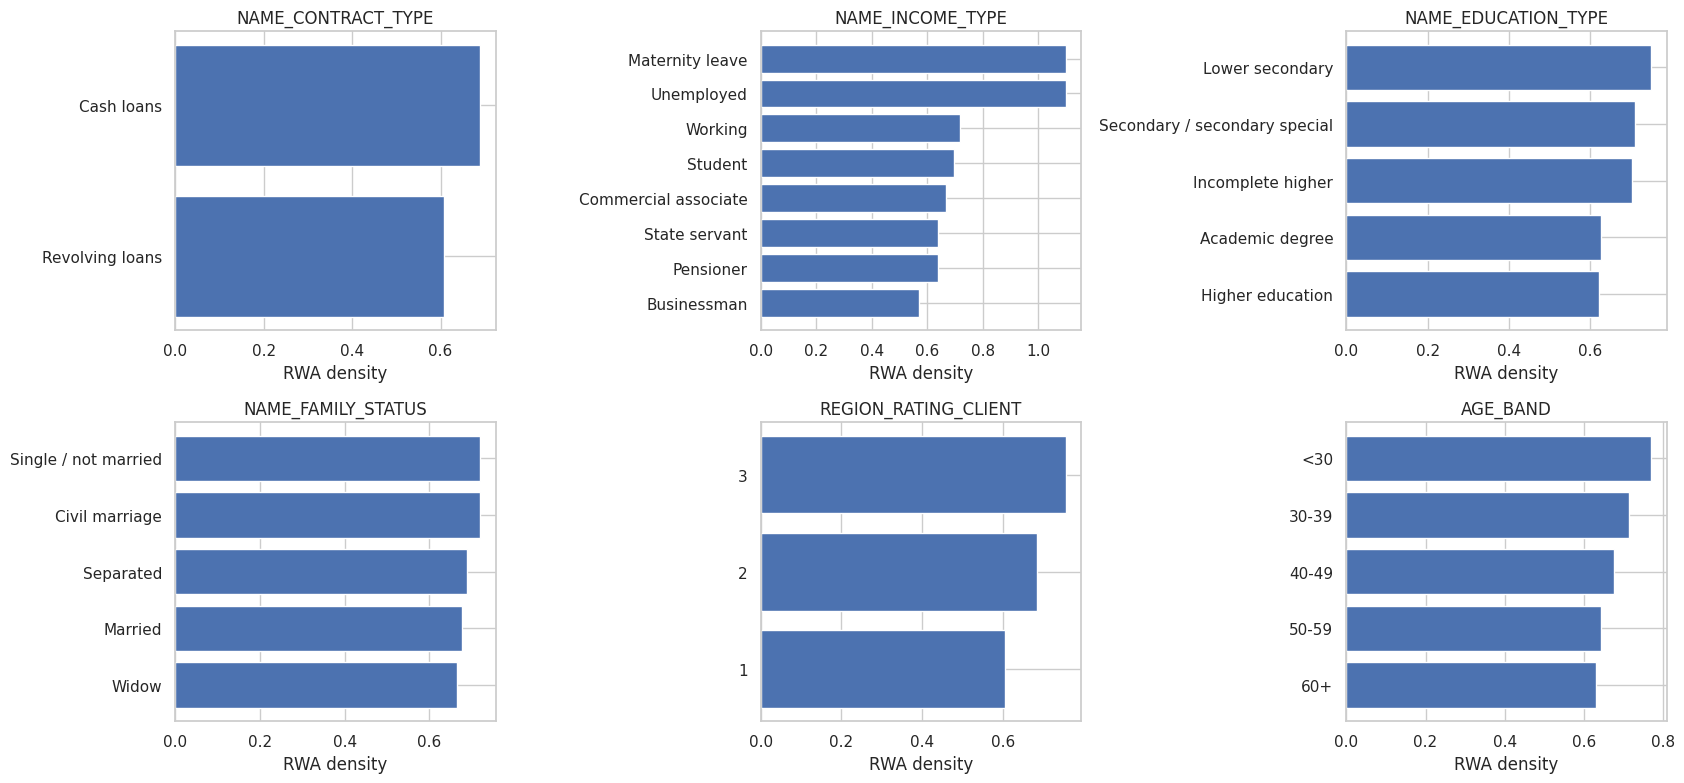

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(17, 8))
for ax, seg in zip(axes.ravel(), SEG_COLS):
    table = port.groupby(seg).agg(count=("SK_ID_CURR", "size"), exposure=("EAD", "sum"), mean_pd=("PD", "mean"), observed=("TARGET", "mean"), el=("EL", "sum"), rwa=("RWA", "sum"))
    table["rwa_density"] = table["rwa"] / table["exposure"]
    table = table.sort_values("rwa_density")
    print(f"\n{seg}\n{table.round(4).to_string()}")
    ax.barh(table.index.astype(str), table["rwa_density"])
    ax.set_title(seg.replace("SEG_", ""))
    ax.set_xlabel("RWA density")
fig.tight_layout()
save(fig, "08_segment_rwa_density")

**Conclusion.** Among segments of meaningful size, capital intensity is highest for applicants under 30 (RWA density 77.1%), region rating 3 (75.7%) and lower secondary education (75.0%), and lowest for region rating 1 (60.7%) and revolving loans (60.9%). Mean predicted PD tracks the observed default rate closely within each sizeable segment, for example 11.19% against 11.00% for region rating 3 and 8.33% against 8.35% for cash loans. The unemployed and maternity leave groups reach 110% but contain only 5 and 2 applicants.

## Export the dashboard artifacts

Aim: write everything the Flask app needs into `artifacts/`: models, blend weight, calibrator, scorecard, feature bounds for the what-if panel, a grade-stratified sample of 5,000 holdout applicants with full features, the scored holdout portfolio, chart data and library versions.

In [15]:
shutil.copy(lgb_path, ART / "lgbm_model.txt")
shutil.copy(xgb_path, ART / "xgb_model.json")
(ART / "blend.json").write_text(json.dumps({"w_lgbm": W}))
(ART / "calibrator.json").write_text(json.dumps(CALIBRATOR, allow_nan=False))
scorecard = {
    "base_score": BASE_SCORE, "base_odds": BASE_ODDS, "pdo": PDO, "factor": FACTOR, "offset": OFFSET,
    "pd_floor": PD_FLOOR, "lgd_default": LGD_DEFAULT, "lgd_floor": LGD_FLOOR, "cutoffs": cutoffs,
    "grades": [{"grade": int(r.grade), "pd": float(r.grade_pd), "score_min": tidy(r.score_min), "score_max": tidy(r.score_max)} for r in master.itertuples()],
}
(ART / "scorecard.json").write_text(json.dumps(scorecard, allow_nan=False))
categorical = {f: meta["categorical"][f] for f in FEATURES if f in meta["categorical"]}
quant = train[FEATURES].quantile([0.005, 0.995])
low, high = quant.loc[0.005].fillna(0.0), quant.loc[0.995].fillna(0.0)
same = low == high
low[same], high[same] = train[FEATURES].min()[same].fillna(0.0), train[FEATURES].max()[same].fillna(0.0)
for f in categorical:
    low[f], high[f] = float(train[f].min()), float(train[f].max())
features_meta = {"features": FEATURES, "low": {f: float(low[f]) for f in FEATURES}, "high": {f: float(high[f]) for f in FEATURES}, "groups": GROUPS, "categorical": categorical}
(ART / "features.json").write_text(json.dumps(features_meta, allow_nan=False))
grade_sub = grade_of(to_score(calibrate(sub["blend"].to_numpy())), cutoffs)
take, _ = train_test_split(np.arange(len(sub)), train_size=APP_SAMPLE, stratify=grade_sub, random_state=SEED)
sub.iloc[np.sort(take)][["SK_ID_CURR", "TARGET", "EAD"] + SEG_COLS + FEATURES].to_parquet(ART / "sample.parquet", index=False)
port[["SK_ID_CURR", "TARGET", "EAD", "PD", "SCORE", "GRADE"] + SEG_COLS].to_parquet(ART / "portfolio.parquet", index=False)


def thin(x, y, n=200):
    idx = np.unique(np.linspace(0, len(x) - 1, n).astype(int))
    return np.asarray(x)[idx], np.asarray(y)[idx]


roc = {}
for name in ["lgbm", "xgb", "blend"]:
    fpr, tpr, _ = roc_curve(hold_pred["TARGET"], hold_pred[name])
    fpr, tpr = thin(fpr, tpr)
    roc[name] = {"fpr": fpr, "tpr": tpr}
precision, recall, _ = precision_recall_curve(hold_pred["TARGET"], hold_pred["blend"])
recall, precision = thin(recall, precision)
rng = np.random.default_rng(SEED)
swarm_rows = rng.choice(len(sub), size=min(600, len(sub)), replace=False)
dep_rows = rng.choice(len(sub), size=min(800, len(sub)), replace=False)
beeswarm = []
for name in mean_abs.index[:15]:
    j = FEATURES.index(name)
    beeswarm.append({"feature": name, "shap": shap_values[swarm_rows, j], "color": sub[name].rank(pct=True).to_numpy()[swarm_rows]})
dependence = {}
for name in mean_abs.index[:20]:
    j = FEATURES.index(name)
    x = sub[name].to_numpy()[dep_rows]
    keep = ~np.isnan(x)
    dependence[name] = {"x": x[keep], "shap": shap_values[dep_rows, j][keep]}
master_out = master.rename(columns={"grade_pd": "pd"}).assign(
    holdout_count=master["grade"].map(val["count"]),
    holdout_rate=master["grade"].map(val["rate"]),
    jeffreys_p=master["grade"].map(val["jeffreys_p"]),
)
charts = {
    "metrics": {**metrics, "holdout_brier_calibrated": float(brier_score_loss(y_hold, pd_hold)), "calibration_method": METHOD},
    "roc": roc,
    "pr": {"blend": {"recall": recall, "precision": precision}},
    "calibration": {"predicted": reliability["predicted"].to_numpy(), "observed": reliability["observed"].to_numpy(), "count": reliability["count"].to_numpy()},
    "folds": fold_metrics.to_dict("records"),
    "shap_global": [{"feature": f, "group": GROUPS[f], "mean_abs": float(mean_abs[f])} for f in mean_abs.index[:30]],
    "beeswarm": beeswarm,
    "dependence": dependence,
    "segment_drivers": drivers,
    "master_scale": master_out[["grade", "score_min", "score_max", "pd", "oof_count", "oof_rate", "holdout_count", "holdout_rate", "jeffreys_p"]].to_dict("records"),
    "psi": PSI,
}
(ART / "charts.json").write_text(json.dumps(tidy(charts), allow_nan=False))
versions = {
    "python": platform.python_version(), "lightgbm": lgb.__version__, "xgboost": xgb.__version__, "numpy": np.__version__,
    "pandas": pd.__version__, "scikit-learn": sklearn.__version__, "scipy": scipy.__version__, "shap": shap.__version__,
}
(ART / "versions.json").write_text(json.dumps(versions, indent=1))
for path in sorted(ART.iterdir()):
    print(f"{path.name:<20} {path.stat().st_size / 1e6:8.2f} MB")
print(json.dumps(versions))

blend.json               0.00 MB
calibrator.json          0.00 MB
charts.json              0.49 MB
features.json            0.12 MB
lgbm_model.txt           6.53 MB
portfolio.parquet        1.87 MB
sample.parquet           6.07 MB
scorecard.json           0.00 MB
versions.json            0.00 MB
xgb_model.json           4.72 MB
{"python": "3.13.15", "lightgbm": "4.6.0", "xgboost": "3.4.1", "numpy": "2.1.3", "pandas": "2.3.3", "scikit-learn": "1.6.1", "scipy": "1.16.3", "shap": "0.52.0"}


**Conclusion.** The ten artifact files total about 20 MB. The models take 6.5 MB (LightGBM) and 4.7 MB (XGBoost), the 5,000-applicant sample 6.1 MB and the scored portfolio 1.9 MB. The library versions used here (Python 3.13.15, LightGBM 4.6.0, XGBoost 3.4.1, pandas 2.3.3, NumPy 2.1.3, SciPy 1.16.3) are recorded so the dashboard can pin them.

## Summary

- Exact TreeSHAP explains the blend additively. The external-score composites dominate, and CODE_GENDER is the second strongest driver, a protected attribute that notebook 4's comparison model quantifies.
- Platt calibration gives PDs that match observed default rates within 0.7 percentage points in every holdout decile; the holdout mean PD is 8.08% against 8.07% observed.
- The 10-grade master scale (600 points at 50:1, 20 points to double the odds) passes every holdout test: monotonic default rates, no Jeffreys failures and a PSI of 0.00025.
- Basel IRB capital for other retail exposures puts the holdout portfolio at a 68.6% RWA density, with risk weights from 41% to 116% across grades and the highest segment intensity for applicants under 30.
- Everything the dashboard needs is exported to `artifacts/`.